In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\Export4.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2585 entries, 0 to 2584
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  2585 non-null   str  
 1   Message  2585 non-null   str  
 2   Status   2585 non-null   str  
dtypes: str(3)
memory usage: 60.7 KB


In [28]:
aux=pd.DataFrame()
aux=raw_data
aux['Headers']='NaN'

for i in range(0,aux.shape[0]):
    aux.iloc[i,3]=aux.iloc[i,2][0:8]

aux['Headers'].value_counts()

Headers
0x252521    1417
0x252513     717
0x252501     220
0x252511     204
0x252514      27
Name: count, dtype: int64

In [29]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2585 entries, 0 to 2584
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  2585 non-null   str  
 1   Message  2585 non-null   str  
 2   Status   2585 non-null   str  
 3   Headers  2585 non-null   str  
dtypes: str(4)
memory usage: 80.9 KB


Odometer

In [30]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux['Odometer in meters']=0.0
odometer=[]
date=[]
raw=[]
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    odometer.append(int(unit_aux.iloc[i,2][96:104],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Odometer in meters']=odometer
unit_aux['Date']=date
unit_aux['Raw data']=raw

#print(unit_aux['Odometer in meters'])

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

<class 'pandas.DataFrame'>
Index: 744 entries, 0 to 2555
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Created             744 non-null    str  
 1   Message             744 non-null    str  
 2   Status              744 non-null    str  
 3   Headers             744 non-null    str  
 4   Odometer in meters  744 non-null    int64
 5   Date                744 non-null    str  
 6   Raw data            744 non-null    str  
dtypes: int64(1), str(6)
memory usage: 46.5 KB
None


260726000041 -> 0 -> 1893541.0 -> 0x252513005918E40869487060207049003C38402D000000294E0000000700644100000000000000FFFFFFFFFFFF00D5001CE4A50026072600004100003C42032693C22A421841061000A203912682FFFFFF0000210000FFFFFF
260726000142 -> 1 -> 1894625.0 -> 0x252513005918E50869487060207049003C38402D000000304E0000000700644100000000000000FFFFFFFFFFFF00D5001CE8E100260726000142CDCC34429E2493C2D61B1841065000A303912747FFFFFF0000210000FFFFFF
260726000242 -> 2 -> 1895693.0 -> 0x252513005918E60869487060207049003C38402D000000414C0000000700644100000000000000FFFFFFFFFFFF00D5001CED0D0026072600024266663E423C2393C211F61741063000A203912747FFFFFF0000210000FFFFFF
260726000342 -> 3 -> 1896563.0 -> 0x252513005918E70869487060207049003C38402D000000334D0000000700644100000000000000FFFFFFFFFFFF00D5001CF0730026072600034200003C421E2293C24AD717410230009D03912757FFFFFF0000220000FFFFFF
260726000442 -> 4 -> 1897106.0 -> 0x252513005918E80869487060207049003C38402D0000004B4D0000000700644100000000000000FFFFFFFFFFFF00D5001CF29200

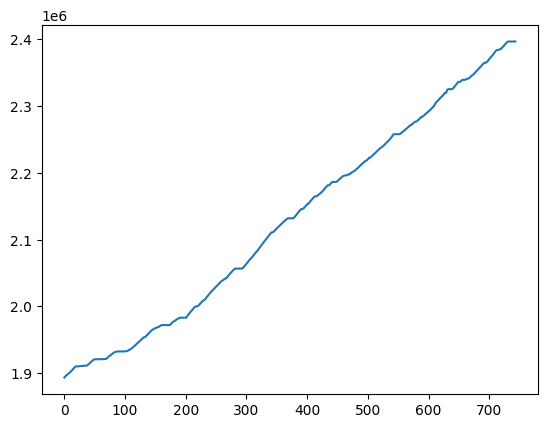

In [31]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,4]))
    x_axis.append(i)
    date.append(unit.iloc[i,5])
    raw_data_.append(unit.iloc[i,6])

#print("Delta odometer: ",y_axis[170]-y_axis[133],'meters')

for i in range(0,len(odometer)):
    print(date[i],'->',x_axis[i],'->',y_axis[i],'->',raw_data_[i])

#print(odometer[len(odometer)-1]-odometer[0])
plt.plot(x_axis,y_axis)

Speed

In [32]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
#unit_aux['Odometer in meters']=0.0
speed=[]
date=[]
raw=[]
unit_speed=pd.DataFrame()
unit=pd.DataFrame()

for i in range(0,unit_aux.shape[0]):
    try:
        lbs_ind=(bin(int(unit_aux.iloc[i,2][50:52],16) & 64))
        if lbs_ind=='0b1000000':
            speed.append(int(unit_aux.iloc[i,2][142:145]))  
            date.append(unit_aux.iloc[i,2][106:118])
            raw.append(unit_aux.iloc[i,2])
            print(lbs_ind)

    except:
        pass    

unit_speed['Speed']=speed
unit_speed['Date']=date
unit_speed['Raw data']=raw

unit=unit_speed.sort_values('Date',ascending=True)

print(unit.info())

0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000
0b1000000


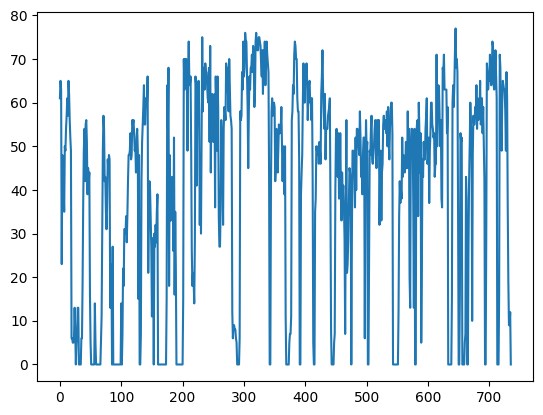

In [33]:
y_axis=[]
x_axis=[]
date=[]
raw_data_=[]

for i in range(0,unit.shape[0]):
    #print(float(fsq694_m_odometer.iloc[i,6][8:15]))
    y_axis.append(float(unit.iloc[i,0]))
    x_axis.append(i)
    date.append(unit.iloc[i,1])
    raw_data_.append(unit.iloc[i,2])

plt.plot(x_axis,y_axis)

Historic events

In [34]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,5]>0:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 744 entries, 0 to 2555
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         744 non-null    str  
 1   Message                         744 non-null    str  
 2   Status                          744 non-null    str  
 3   Headers                         744 non-null    str  
 4   Satellites                      744 non-null    int64
 5   Satellite_connection_indicator  744 non-null    int64
 6   Raw data                        744 non-null    str  
 7   date                            744 non-null    str  
dtypes: int64(2), str(6)
memory usage: 52.3 KB
128 -> 2026-07-26 02:01:17.326 -> 17 -> 0x252513005919480869487060207049003C38402D00000037D10000000700644100000000000000FFFFFFFFFFFF00D5001D869C0026072602010066667442D82193C2082013410300010103912742FFFFFF00001E0000FFFFFF
128 -> 2026-07-26 02:01:17.566 -> 17 -> 0x25251300591

Satellites Number

In [35]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
satellite_number=[]
satellite_connection_indicator=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    satellite_number.append(int(unit_aux.iloc[i,2][50:52],16) & 31)
    satellite_connection_indicator.append(int(unit_aux.iloc[i,2][50:52],16) & 128)
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Satellites']=satellite_number
unit_aux['Satellite_connection_indicator']=satellite_connection_indicator
unit_aux['Raw data']=raw
unit_aux['date']=date

unit=unit_aux.sort_values('date',ascending=True)

unit.info()

for i in range(0,unit.shape[0]):
    if unit.iloc[i,4]<2:
        num_events=num_events+1
        print(unit.iloc[i,5],'->', unit.iloc[i,0], '->',unit.iloc[i,4],'->',unit.iloc[i,6])

print("Eventos históricos: ",num_events)

<class 'pandas.DataFrame'>
Index: 744 entries, 0 to 2555
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Created                         744 non-null    str  
 1   Message                         744 non-null    str  
 2   Status                          744 non-null    str  
 3   Headers                         744 non-null    str  
 4   Satellites                      744 non-null    int64
 5   Satellite_connection_indicator  744 non-null    int64
 6   Raw data                        744 non-null    str  
 7   date                            744 non-null    str  
dtypes: int64(2), str(6)
memory usage: 52.3 KB
0 -> 2026-07-26 20:59:36.735 -> 0 -> 0x25251300591BB00869487060207049003C38402D00000030000000000000640000000000000000FFFFFFFFFFFF00D5002491CE0026072620593582DC0065000B1166552800840097005F03912550FFFFFF000020FFFFFFFFFF
0 -> 2026-07-27 00:59:34.748 -> 0 -> 0x25251300591BB1086

Coordinates

In [36]:
import struct

unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
latitude=[]
lat_aux=[]
longitude=[]
lon_aux=[]
speed=[]
date=[]
raw=[]
num_events=0

for i in range(0,unit_aux.shape[0]):
    latitude.append(unit_aux.iloc[i,2][134:142])
    longitude.append(unit_aux.iloc[i,2][126:134])
    lon_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][126:134]))[0])
    lat_aux.append(struct.unpack('<f', bytes.fromhex(unit_aux.iloc[i,2][134:142]))[0])    
    speed.append(int(unit_aux.iloc[i,2][142:145],16))
    date.append(unit_aux.iloc[i,2][106:118])
    raw.append(unit_aux.iloc[i,2])    

unit_aux['Latitude']=latitude
unit_aux['Latitude_decoded']=lat_aux
unit_aux['Longitude']=longitude
unit_aux['Longitude_decoded']=lon_aux
unit_aux['Raw data']=raw
unit_aux['Date']=date
unit_aux['Speed']=speed

unit=unit_aux.sort_values('Date',ascending=True)

print(unit.info())

for i in range(0,unit.shape[0]):
    num_events=num_events+1
    print(unit.iloc[i,9],'->', unit.iloc[i,4], '->',unit.iloc[i,5],'->',unit.iloc[i,6],'->',unit.iloc[i,7],unit.iloc[i,8])

<class 'pandas.DataFrame'>
Index: 744 entries, 0 to 2555
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Created            744 non-null    str    
 1   Message            744 non-null    str    
 2   Status             744 non-null    str    
 3   Headers            744 non-null    str    
 4   Latitude           744 non-null    str    
 5   Latitude_decoded   744 non-null    float64
 6   Longitude          744 non-null    str    
 7   Longitude_decoded  744 non-null    float64
 8   Raw data           744 non-null    str    
 9   Date               744 non-null    str    
 10  Speed              744 non-null    int64  
dtypes: float64(2), int64(1), str(8)
memory usage: 69.8 KB
None
260726000041 -> 2A421841 -> 9.516153335571289 -> 032693C2 -> -73.5742416381836 0x252513005918E40869487060207049003C38402D000000294E0000000700644100000000000000FFFFFFFFFFFF00D5001CE4A50026072600004100003C42032693C22A4218410

In/Outs

15      14                 13      12      11      10      09      08       07 06 05 04 03 02 01 00
Power   Ignition/Input0    Input1  Input2  Input3  Input4  Input5  Input0

15=0, Connected
15=1. Disconnected

In [37]:
unit_13=raw_data[raw_data['Status'].str.contains('0x252513')]
unit_14=raw_data[raw_data['Status'].str.contains('0x252514')]
unit_aux=pd.concat([unit_13,unit_14])
unit_aux.info()
aux_cad=[]
aux_date=[]
aux_raw_data=[]
aux_input_number=[]
in_outs=[]

#unit_aux.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\concatenated.csv')

for i in range(0,unit_aux.shape[0]):
    long_cad=len(unit_aux.iloc[i,2])
    if ((long_cad>48) & (long_cad<204)):
        aux_cad.append(unit_aux.iloc[i,2])   

for i in range(0,len(aux_cad)):
    aux_value=aux_cad[i][64:68]
    aux_date.append(aux_cad[i][106:118])
    aux_raw_data.append(aux_cad[i])
    in_outs.append(bin (int (aux_cad[i][64:68],16) ))      

unit_=pd.DataFrame()
unit_['in and outs']=in_outs
unit_['date']=aux_date
unit_['raw data']=aux_raw_data

in_outs_df=unit_.sort_values('date',ascending=True)

in_outs_df.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\sym\in_outs.csv')

<class 'pandas.DataFrame'>
Index: 744 entries, 0 to 1374
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  744 non-null    str  
 1   Message  744 non-null    str  
 2   Status   744 non-null    str  
 3   Headers  744 non-null    str  
dtypes: str(4)
memory usage: 29.1 KB
